# Research 02 — Do Oversold Stocks Bounce Back? (Mean Reversion)

## Hypothesis
- **H0:** Stocks that dropped significantly show no tendency to recover.
- **H1:** Stocks that underperformed over a short window (1–4 weeks) tend to
  revert toward their mean — producing positive excess returns in the following weeks.

## Background
Mean reversion is the opposite of momentum. While momentum says "winners keep winning",
mean reversion says "losers bounce back". Both can coexist at different time horizons:
- **Short-term (1–4 weeks):** Reversal / Mean Reversion
- **Medium-term (3–12 months):** Momentum
- **Long-term (3–5 years):** Reversal again

## Approach
1. Compute short-term past returns (5d, 10d, 21d lookback)
2. Identify "oversold" stocks (bottom 20% by recent return)
3. Measure their forward returns (5d, 10d, 21d)
4. Compare oversold vs overbought forward returns
5. Statistical tests
6. Check if combining with RSI improves the signal
7. Conclude

---


In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import yfinance as yf

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded.')


Libraries loaded.


## 1. Download Data


In [2]:
# Same 24 large-cap US stocks as notebook 01
TICKERS = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'AMD',
    'JPM', 'BAC', 'GS', 'V', 'MA',
    'JNJ', 'PFE', 'UNH', 'MRK',
    'XOM', 'CVX',
    'WMT', 'COST', 'HD',
    'TSLA', 'NFLX', 'ADBE',
]

START = '2015-01-01'
END   = '2024-12-31'

raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close'].dropna(axis=1, how='all').ffill()
volume = raw['Volume'].dropna(axis=1, how='all').ffill()

print(f'Downloaded {prices.shape[1]} tickers | {prices.shape[0]} days')
print(f'Period: {prices.index[0].date()} -> {prices.index[-1].date()}')


Downloaded 24 tickers | 2515 days
Period: 2015-01-02 -> 2024-12-30


## 2. Signal Construction — Short-Term Drawdown

We look at stocks that dropped the most over a SHORT window (5–21 days).
Unlike momentum (6-month lookback), mean reversion uses much shorter horizons.


In [3]:
LOOKBACKS = [5, 10, 21]   # short-term windows (days)
HOLD = 10                  # default forward holding: 10 days (~2 weeks)

# Compute short-term past returns for each lookback
past_returns = {}
for lb in LOOKBACKS:
    past_returns[lb] = prices.pct_change(lb)

# Forward returns for multiple holding periods
fwd_ret = {}
for hd in [5, 10, 21]:
    fwd_ret[hd] = prices.pct_change(hd).shift(-hd)

print('Signals computed for lookbacks:', LOOKBACKS)
print('Forward returns computed for holding:', list(fwd_ret.keys()))


Signals computed for lookbacks: [5, 10, 21]
Forward returns computed for holding: [5, 10, 21]


## 3. Identify Oversold vs Overbought Stocks

Each day, rank stocks by their short-term return:
- **Oversold** = bottom 20% (biggest losers recently)
- **Overbought** = top 20% (biggest winners recently)

If mean reversion exists, oversold should outperform overbought going forward.


In [ ]:
def compute_spread(past_ret_df, fwd_ret_df):
    ranks = past_ret_df.rank(axis=1, pct=True)
    oversold_mask = ranks <= 0.20    # bottom (biggest losers)
    overbought_mask = ranks >= 0.80  # top (biggest winners)

    oversold_fwd = fwd_ret_df[oversold_mask].mean(axis=1).dropna()
    overbought_fwd = fwd_ret_df[overbought_mask].mean(axis=1).dropna()

    # Mean reversion spread: long oversold, short overbought
    spread = (oversold_fwd - overbought_fwd).dropna()
    return spread, oversold_fwd, overbought_fwd

# Primary signal: 10-day lookback, 10-day holding
spread_10_10, oversold_fwd, overbought_fwd = compute_spread(
    past_returns[10], fwd_ret[10]
)

print(f'Mean Reversion Spread (10d/10d)')
print(f'  Mean   : {spread_10_10.mean()*100:+.3f}%')
print(f'  Std    : {spread_10_10.std()*100:.3f}%')
print(f'  Sharpe : {spread_10_10.mean()/spread_10_10.std()*np.sqrt(252/10):.2f}')
print(f'  Obs    : {len(spread_10_10)}')


Mean Reversion Spread (10d/10d)
  Mean   : -0.186%
  Std    : 5.227%
  Sharpe : -0.18
  Obs    : 2495


## 4. Statistical Testing


In [5]:
def test_spread(spread, label, hold_days):
    """Run t-test on NON-overlapping windows (see NB01 for why overlap lies)."""
    indep = spread.iloc[::hold_days].dropna()   # non-overlapping obs only
    t, p = stats.ttest_1samp(indep, 0)
    sharpe = indep.mean() / indep.std() * np.sqrt(252 / hold_days)
    print(f'--- {label} ---')
    print(f'  Mean spread : {indep.mean()*100:+.4f}%')
    print(f'  t-stat      : {t:.3f}')
    print(f'  p-value     : {p:.4g}  {"SIGNIFICANT" if p < 0.05 else "NOT significant"}')
    print(f'  Ann. Sharpe : {sharpe:.2f}')
    print(f'  % positive  : {(indep > 0).mean():.1%}')
    print()
    return {'label': label, 'mean': indep.mean(), 'sharpe': sharpe, 't': t, 'p': p}

# Test primary signal
test_spread(spread_10_10, 'Lookback=10d, Hold=10d', 10)

# Full grid: all lookback x holding combinations
print('='*60)
print('FULL GRID: Lookback x Holding')
print('='*60)
results = []
for lb in LOOKBACKS:
    for hd in [5, 10, 21]:
        sp, _, _ = compute_spread(past_returns[lb], fwd_ret[hd])
        r = test_spread(sp, f'LB={lb}d / Hold={hd}d', hd)
        r['lookback'] = lb
        r['holding'] = hd
        results.append(r)


--- Lookback=10d, Hold=10d ---
  Mean spread : -0.1919%
  t-stat      : -0.513
  p-value     : 0.6087  NOT significant
  Ann. Sharpe : -0.16
  % positive  : 47.6%

FULL GRID: Lookback x Holding
--- LB=5d / Hold=5d ---
  Mean spread : +0.0805%
  t-stat      : 0.438
  p-value     : 0.6613  NOT significant
  Ann. Sharpe : 0.14
  % positive  : 50.9%

--- LB=5d / Hold=10d ---
  Mean spread : -0.2837%
  t-stat      : -0.949
  p-value     : 0.3434  NOT significant
  Ann. Sharpe : -0.30
  % positive  : 49.6%

--- LB=5d / Hold=21d ---
  Mean spread : -1.1418%
  t-stat      : -1.522
  p-value     : 0.1306  NOT significant
  Ann. Sharpe : -0.48
  % positive  : 46.2%

--- LB=10d / Hold=5d ---
  Mean spread : +0.0006%
  t-stat      : 0.003
  p-value     : 0.9974  NOT significant
  Ann. Sharpe : 0.00
  % positive  : 48.6%

--- LB=10d / Hold=10d ---
  Mean spread : -0.1919%
  t-stat      : -0.513
  p-value     : 0.6087  NOT significant
  Ann. Sharpe : -0.16
  % positive  : 47.6%

--- LB=10d / Hold=21

## 5. Visualisation


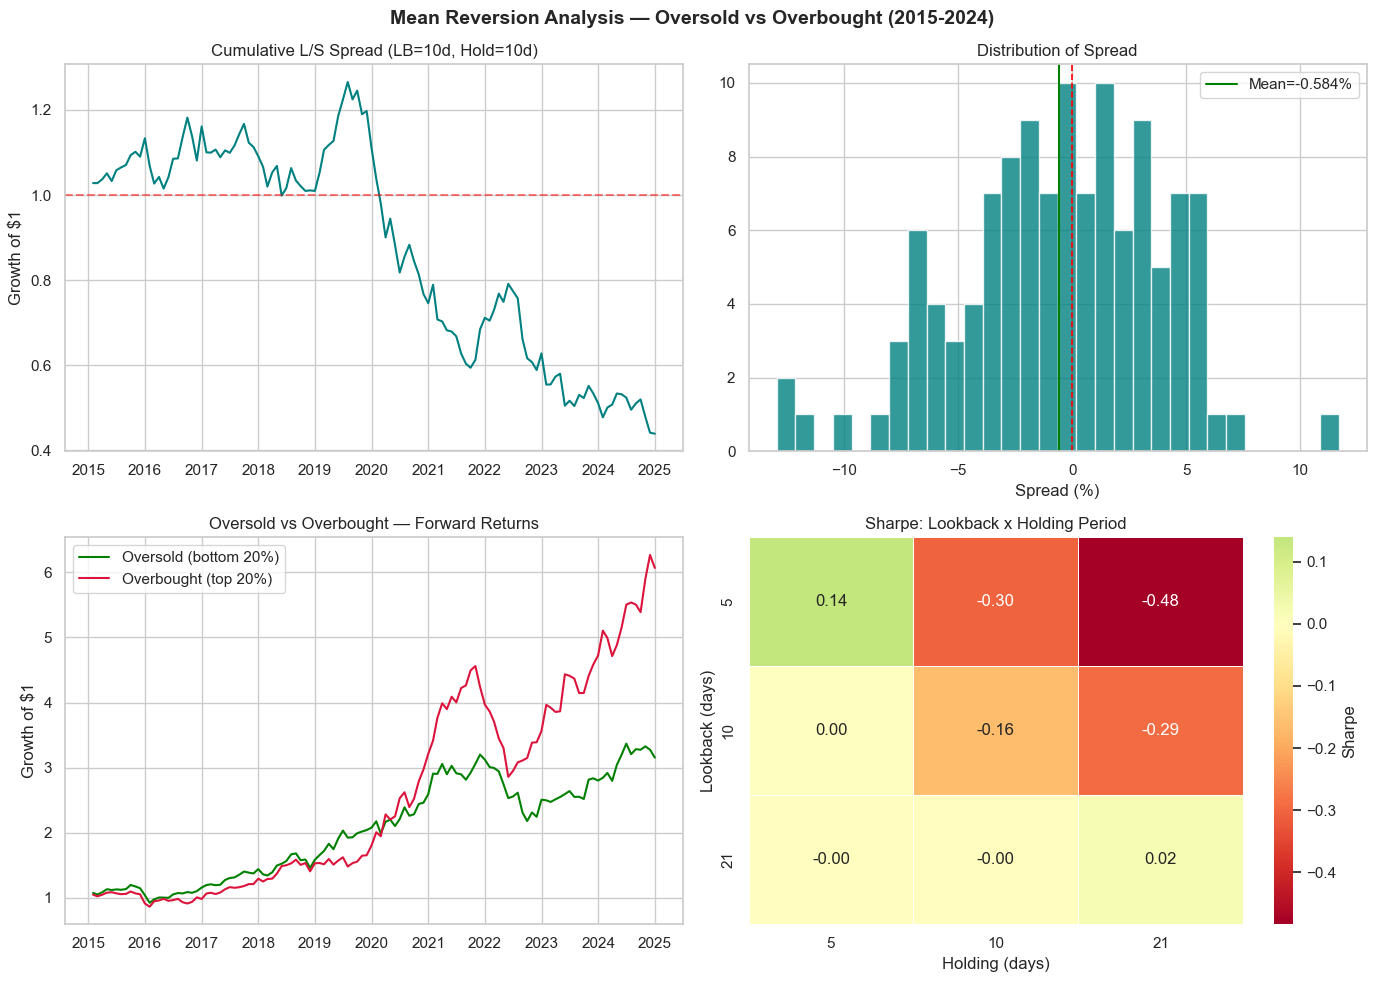

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Mean Reversion Analysis — Oversold vs Overbought (2015-2024)',
             fontsize=14, fontweight='bold')

# Resample to monthly non-overlapping for cumulative plots
spread_monthly = spread_10_10.resample('ME').last().dropna()
oversold_monthly = oversold_fwd.resample('ME').last().dropna()
overbought_monthly = overbought_fwd.resample('ME').last().dropna()

# Plot 1: Cumulative L/S spread
ax = axes[0, 0]
cum = (1 + spread_monthly).cumprod()
ax.plot(cum.index, cum.values, color='teal', lw=1.5)
ax.axhline(1, color='red', ls='--', alpha=0.5)
ax.set_title('Cumulative L/S Spread (LB=10d, Hold=10d)')
ax.set_ylabel('Growth of $1')

# Plot 2: Distribution of spread
ax = axes[0, 1]
ax.hist(spread_monthly * 100, bins=30, edgecolor='white', alpha=0.8, color='teal')
ax.axvline(0, color='red', ls='--', lw=1.2)
ax.axvline(spread_monthly.mean() * 100, color='green', lw=1.5,
           label=f'Mean={spread_monthly.mean()*100:.3f}%')
ax.set_title('Distribution of Spread')
ax.set_xlabel('Spread (%)')
ax.legend()

# Plot 3: Oversold vs Overbought cumulative
ax = axes[1, 0]
ax.plot((1 + oversold_monthly).cumprod().index,
        (1 + oversold_monthly).cumprod().values,
        color='green', lw=1.5, label='Oversold (bottom 20%)')
ax.plot((1 + overbought_monthly).cumprod().index,
        (1 + overbought_monthly).cumprod().values,
        color='crimson', lw=1.5, label='Overbought (top 20%)')
ax.set_title('Oversold vs Overbought — Forward Returns')
ax.set_ylabel('Growth of $1')
ax.legend()

# Plot 4: Heatmap of Sharpe across lookback x holding
ax = axes[1, 1]
res_df = pd.DataFrame(results)
hm = res_df.pivot(index='lookback', columns='holding', values='sharpe')
sns.heatmap(hm, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Sharpe'})
ax.set_title('Sharpe: Lookback x Holding Period')
ax.set_xlabel('Holding (days)')
ax.set_ylabel('Lookback (days)')

plt.tight_layout()
plt.show()


## 6. RSI Enhancement

Can we improve the signal by combining price drop with RSI < 30?
RSI adds a "speed of decline" filter — stocks that dropped fast are more likely to bounce.


In [7]:
def compute_rsi(prices_df, period=14):
    """Compute RSI for all stocks in a DataFrame."""
    delta = prices_df.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

rsi = compute_rsi(prices, period=14)
print(f'RSI computed. Shape: {rsi.shape}')
print(f'Current RSI range: {rsi.iloc[-1].min():.1f} - {rsi.iloc[-1].max():.1f}')


RSI computed. Shape: (2515, 24)
Current RSI range: 10.8 - 64.9


In [8]:
# Combined signal: oversold by BOTH short-term return AND RSI < 30
ranks = past_returns[10].rank(axis=1, pct=True)
oversold_price = ranks <= 0.20
oversold_rsi = rsi < 30
combined_signal = oversold_price & oversold_rsi

# Forward returns for each signal type
combined_fwd = fwd_ret[10][combined_signal].mean(axis=1).dropna()
price_only_fwd = fwd_ret[10][oversold_price].mean(axis=1).dropna()

print(f'Price-only oversold signals per day (avg): {oversold_price.sum(axis=1).mean():.1f}')
print(f'Combined signals per day (avg): {combined_signal.sum(axis=1).mean():.1f}')
print()
print(f'Price-only avg forward return: {price_only_fwd.mean()*100:+.3f}%')
print(f'Combined (price+RSI) avg forward return: {combined_fwd.mean()*100:+.3f}%')
print()

combined_indep = combined_fwd.iloc[::10].dropna()   # non-overlapping (10d hold)
if len(combined_indep) > 30:
    t, p = stats.ttest_1samp(combined_indep, 0)
    print(f'Combined signal t-test (non-overlapping): t={t:.3f}  p={p:.4g}')
    print(f'  {"SIGNIFICANT" if p < 0.05 else "NOT significant"}')
else:
    print(f'Not enough independent combined obs ({len(combined_indep)}) for a reliable test.')


Price-only oversold signals per day (avg): 4.0
Combined signals per day (avg): 1.1

Price-only avg forward return: +1.069%
Combined (price+RSI) avg forward return: +0.851%

Combined signal t-test (non-overlapping): t=1.038  p=0.3009
  NOT significant


## 7. Reversal Decay — How Quickly Does Mean Reversion Fade?

We check: After the bounce, does the stock continue up or fade back?
This tells us the optimal holding period.


In [9]:
# Measure excess return of oversold stocks at different forward horizons
horizons = [1, 2, 3, 5, 10, 15, 21, 42, 63]
decay_data = []

for h in horizons:
    fr_h = prices.pct_change(h).shift(-h)
    oversold_h = fr_h[oversold_price].mean(axis=1).dropna()
    market_h = fr_h.mean(axis=1).dropna()
    # Align indexes before subtracting
    common_idx = oversold_h.index.intersection(market_h.index)
    excess = oversold_h.loc[common_idx] - market_h.loc[common_idx]
    decay_data.append({
        'horizon': h,
        'oversold_ret': oversold_h.mean() * 100,
        'market_ret': market_h.mean() * 100,
        'excess_ret': excess.mean() * 100,
    })

decay_df = pd.DataFrame(decay_data)
print(decay_df.to_string(index=False))


 horizon  oversold_ret  market_ret  excess_ret
       1        0.1315      0.0979      0.0319
       2        0.2591      0.1952      0.0614
       3        0.3780      0.2945      0.0811
       5        0.5927      0.4899      0.1007
      10        1.0687      0.9800      0.0876
      15        1.5779      1.4800      0.1012
      21        2.3746      2.0842      0.3032
      42        4.6900      4.1416      0.5551
      63        7.1491      6.2414      0.9094


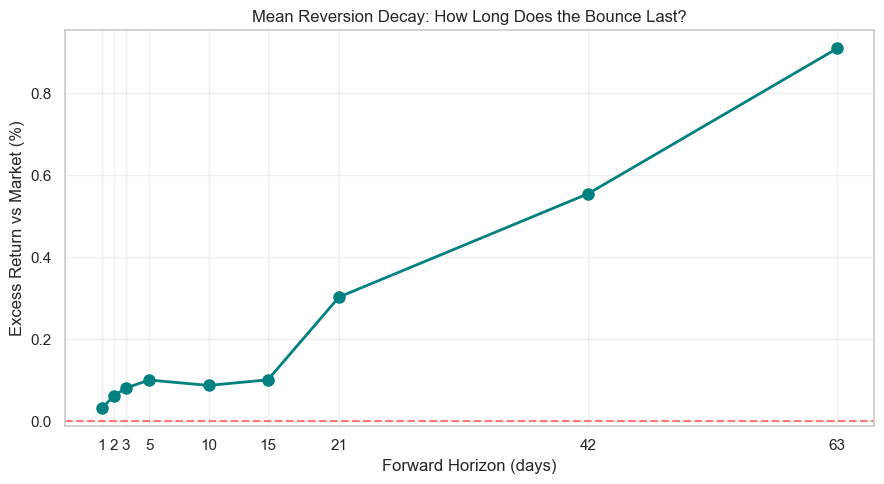

Peak excess return at horizon: 63 days


In [10]:
# Decay chart: excess return vs forward horizon
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(decay_df['horizon'], decay_df['excess_ret'], 'o-', color='teal', lw=2, ms=8)
ax.axhline(0, color='red', ls='--', alpha=0.5)
ax.set_xlabel('Forward Horizon (days)')
ax.set_ylabel('Excess Return vs Market (%)')
ax.set_title('Mean Reversion Decay: How Long Does the Bounce Last?')
ax.set_xticks(horizons)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Peak excess return at horizon:', decay_df.loc[decay_df['excess_ret'].idxmax(), 'horizon'], 'days')


## 8. Conclusion

### Key Questions
| Question | Answer |
|----------|--------|
| Do oversold stocks bounce back? | *(fill after running)* |
| Best lookback/holding combo? | *(fill after running)* |
| Does RSI filter improve signal? | *(fill after running)* |
| Optimal holding period (decay chart)? | *(fill after running)* |
| Statistically significant? | *(fill after running)* |

### Mean Reversion vs Momentum — Can They Coexist?
- Momentum works at 3–12 month horizons
- Mean Reversion works at 1–4 week horizons
- A combined strategy could use BOTH:
  - Long-term: follow momentum (hold winners)
  - Short-term: buy dips in momentum winners (mean reversion entry timing)

### If mean reversion exists -> Next steps:
- [ ] Refine `BollingerMeanReversion` strategy with optimal lookback from this research
- [ ] Add RSI filter to entry conditions
- [ ] Set holding period based on decay analysis
- [ ] Walk-forward test
- [ ] Compare: pure momentum vs pure MR vs combined


In [11]:
# Final summary
print('='*50)
print('      MEAN REVERSION RESEARCH SUMMARY')
print('='*50)
sp = spread_10_10.iloc[::10].dropna()   # non-overlapping 10-day windows
t_val, p_val = stats.ttest_1samp(sp, 0)
sharpe = sp.mean() / sp.std() * np.sqrt(252/10)
peak_h = decay_df.loc[decay_df['excess_ret'].idxmax(), 'horizon']
print(f'  Signal             : Long Oversold / Short Overbought')
print(f'  Lookback           : 10 days')
print(f'  Holding            : 10 days')
print(f'  Mean Spread        : {sp.mean()*100:+.3f}%')
print(f'  Ann. Sharpe        : {sharpe:.2f}')
print(f'  t-stat             : {t_val:.3f}')
print(f'  p-value            : {p_val:.4g}')
print(f'  % Positive         : {(sp > 0).mean():.1%}')
print(f'  Optimal Hold (decay): {peak_h} days')
print('='*50)
if p_val < 0.05:
    print('  CONCLUSION: Mean reversion IS statistically significant.')
else:
    print('  CONCLUSION: Cannot confirm mean reversion at this significance level.')


      MEAN REVERSION RESEARCH SUMMARY
  Signal             : Long Oversold / Short Overbought
  Lookback           : 10 days
  Holding            : 10 days
  Mean Spread        : -0.192%
  Ann. Sharpe        : -0.16
  t-stat             : -0.513
  p-value            : 0.6087
  % Positive         : 47.6%
  Optimal Hold (decay): 63 days
  CONCLUSION: Cannot confirm mean reversion at this significance level.
